# 🧪 LAB 4: Feature Extraction & Segmentation

---

## **Part 1: Hu Moments & Rotation Invariance with Letters**


### **Objectives**
- Observe the invariance of Hu moments for shape recognition.
- Compare invariance between similar and different shapes.

---

### **Instructions**

1. **Use letter images**
2. **Binarize the images** (thresholding).
3. **Find the contours** of the letters.
4. **Compute the Hu moments** for each main contour.
5. **Compare the results** in a pandas DataFrame.
6. **Answer the questions below.**

### **Questions**
1. Are the Hu moments of the different “A”s similar despite the rotation?

2. How does the “K” Hu moment vector compare?

3. What does this experiment show about the use of Hu moments in shape recognition?



In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from google.colab.patches import cv2_imshow


In [ ]:
img1=files.upload()

Saving rotated_letters.png to rotated_letters.png


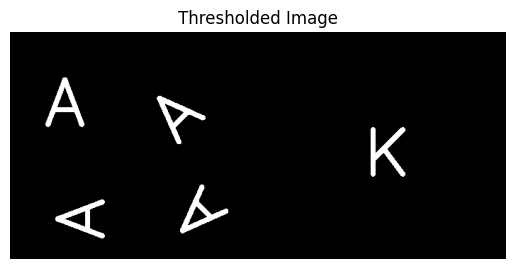

In [ ]:
# Load the provided image (should be in your working directory)
img = cv2.imread('rotated_letters.png', 0)

# Threshold to get a binary image (letters in white on black)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

# Show the binary image
plt.imshow(binary, cmap='gray')
plt.title("Thresholded Image")
plt.axis('off')
plt.show()

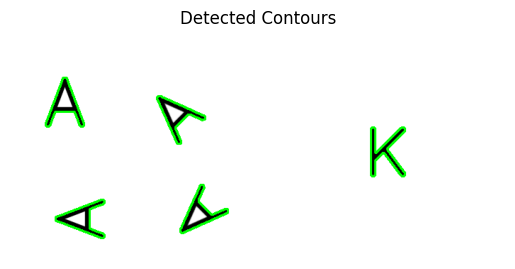

In [ ]:
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours for visualization
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img_color, contours, -1, (0,255,0), 2)

plt.imshow(img_color)
plt.title("Detected Contours")
plt.axis('off')
plt.show()

In [ ]:
def contour_centroid(c):
    M = cv2.moments(c)
    if M['m00'] == 0:
        return (0, 0)
    cx = int(M['m10']/M['m00'])
    cy = int(M['m01']/M['m00'])
    return (cy, cx)  # (row, col) for sorting

contours = sorted(contours, key=contour_centroid)  #top to bottom ,left to right

# Prepare for analysis
hu_moments_list = []
labels = ['A (0°)', 'A (45°)',  'K','A (90°)', 'A (135°)']

for i, cnt in enumerate(contours):
    # Compute Hu moments
    moments = cv2.moments(cnt)
    hu = cv2.HuMoments(moments).flatten()
    # Take the log scale for better comparison (common practice)
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
    hu_moments_list.append(hu_log)

# Create DataFrame
df_hu = pd.DataFrame(hu_moments_list, columns=[f'Hu{i+1}' for i in range(7)], index=labels)
print(df_hu)


               Hu1       Hu2       Hu3       Hu4       Hu5       Hu6  \
A (0°)    0.537772  2.232242  1.753077  2.872452 -5.185211  3.988573   
A (45°)   0.540081  2.253609  1.758467  2.870857 -5.185613  3.997673   
K         0.279665  1.999684  1.937748  2.381660 -4.592006 -3.387778   
A (90°)   0.540081  2.253609  1.758467  2.870857 -5.185613  3.997673   
A (135°)  0.537772  2.232242  1.753077  2.872452 -5.185211  3.988573   

                Hu7  
A (0°)    10.000000  
A (45°)   -6.851892  
K          4.882304  
A (90°)   -6.851892  
A (135°)  10.000000  


### **Answer**
1. Are the Hu moments of the different “A”s similar despite the rotation?

> Yes! The Hu moments of all the “A”s (even at 0°, 45°, 90°, and 135° rotation) are nearly identical. This shows that Hu moments are highly stable under rotation.


2. How does the “K” Hu moment vector compare?

> The Hu moment vector for the “K” is very different from the “A”s. Its values differ significantly across most of the 7 Hu moments, reflecting that “K” has a different shape structure than “A” (even though both are single letters).


3. What does this experiment show about the use of Hu moments in shape recognition?

> This experiment demonstrates that Hu moments are powerful for recognizing shapes independently of their orientation (rotation, translation, scale).  
> They are well suited for tasks where the same object may appear in different poses, because the feature vector remains (almost) unchanged under rotation.  
> This property makes them useful for shape matching, classification, and some OCR tasks where orientation may vary.


## **Part 2: Segmentation of Blood Vessels in a Retinal Image**


## **Objectives**
- Apply basic image filtering and thresholding to extract blood vessels.
- Use edge detection (Canny) to find vessel boundaries.
- Compare methods and discuss the strengths/weaknesses of each approach.

---

### **Instructions**

1. **Load** a retina (fundus) image (e.g., `'retina.jpg'`).
2. **Convert** the image to grayscale.
3. **Apply** Gaussian blur to reduce noise.
4. **Apply** adaptive thresholding to highlight vessels.
5. **Apply** Canny edge detection to extract blood vessel edges.
6. **Display** all results.

### **Questions**
1. Which method best separates blood vessels from the background?  
2. What problems do you notice (noise, uneven lighting, contrast, vessel thickness)?


In [ ]:
img1=files.upload()

Saving retina_vessel.jpg to retina_vessel.jpg


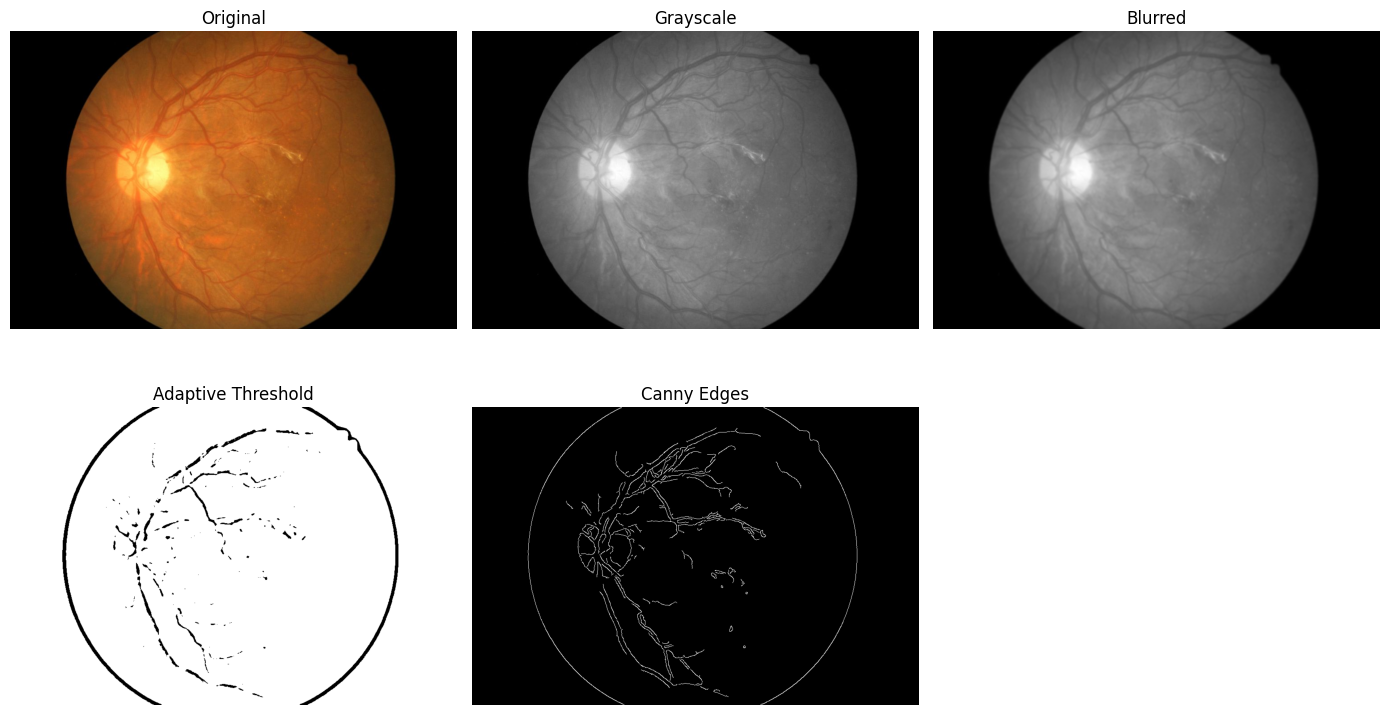

In [ ]:
# 1. Load image
img = cv2.imread('retina_vessel.jpg')  # Use the path to your image

# 2. Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3a. Gaussian blur
blurred = cv2.GaussianBlur(gray, (7, 7), 0)

# 3b. Adaptive thresholding
thresh = cv2.adaptiveThreshold(
    blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY, 21, 8
)


# 3c. Canny edge detection
edges = cv2.Canny(blurred, 10, 40)

# 4. Display results
plt.figure(figsize=(14, 8))
plt.subplot(2,3,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title('Original'); plt.axis('off')
plt.subplot(2,3,2); plt.imshow(gray, cmap='gray'); plt.title('Grayscale'); plt.axis('off')
plt.subplot(2,3,3); plt.imshow(blurred, cmap='gray'); plt.title('Blurred'); plt.axis('off')
plt.subplot(2,3,4); plt.imshow(thresh, cmap='gray'); plt.title('Adaptive Threshold'); plt.axis('off')
plt.subplot(2,3,5); plt.imshow(edges, cmap='gray'); plt.title('Canny Edges'); plt.axis('off')
plt.tight_layout(); plt.show()

### **Questions**
1. Which method best separates blood vessels from the background?  

> Among the methods tested, adaptive thresholding does a better job of highlighting the blood vessels than Canny edge detection. Adaptive thresholding can pick up the fine, faint vessel structures due to local intensity adaptation, while Canny detects only a few strong edges (mostly along the border or thickest vessels).

2. What problems do you notice (noise, uneven lighting, contrast, vessel thickness)?

Noise: Small specks and artifacts appear, especially outside the vessel areas or along the border of the circular field of view.

Uneven lighting: The optic disc (bright spot) is much brighter than the rest, making local thresholds inconsistent across the image.

Low contrast: Some vessels are faint and hard to distinguish from the background, especially the thinner ones.

Vessel thickness: Thin vessels may be lost, and thick ones may appear broken or merged with the background.

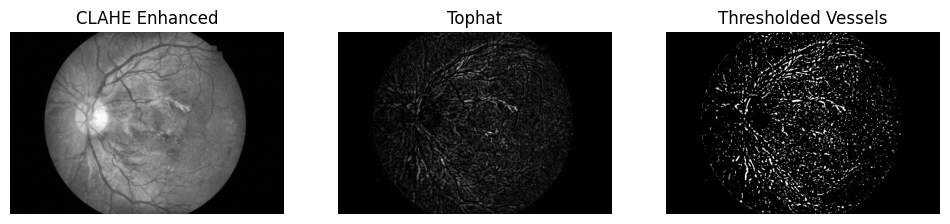

In [ ]:
# 1. CLAHE Contrast enhancement
'''
It works by dividing the image into small regions (tiles)
and applying histogram equalization to each one, but with a limit to prevent over-amplifying noise

'''
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(gray)

# 2. Morphological tophat
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (13,13))
tophat = cv2.morphologyEx(enhanced, cv2.MORPH_TOPHAT, kernel)

# 3. Adaptive thresholding
thresh = cv2.adaptiveThreshold(
    tophat, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY, 21, -8
)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(enhanced, cmap='gray'); plt.title('CLAHE Enhanced'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(tophat, cmap='gray'); plt.title('Tophat'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(thresh, cmap='gray'); plt.title('Thresholded Vessels'); plt.axis('off')
plt.show()

## **Part 3: Image Segmentation by Color using K-means Clustering**


## **Objectives**
Segment an image into regions of similar color using the K-means clustering algorithm. Visualize the segmented output, compare different values of K, and understand how K-means can be used as a basic image segmentation method.
---

### **Instructions**

1. **Load Image (lab4_landscape)**  

2. **Reshape the Image Data**  
   - Convert the image to a 2D array (pixels × 3 channels).

3. **Apply K-means Clustering**  
   - Find the best  value of K .
   - Fit K-means to cluster pixels by color.

4. **Visualize the Segmented Image**  
   - Reconstruct the image using the color of each cluster center.
   - Display the result.

5. **Try with at least two different K values**  
   - See how the segmentation changes.

6. **Find the best K value**  
   - Elbow curve.


6. **Donut or Pie Chart**  
   - Show the proportion of each color in the image.

### **Questions**
1. What do you observe about the segmented images for different values of K?

2. Which value of K best separates visually meaningful regions in the image?

3. What are some limitations of using K-means for segmentation?

4. Try segmenting an image with texture or less color variation—what happens?

In [ ]:
img1=files.upload()

Saving lab4_landscape.jpeg to lab4_landscape.jpeg


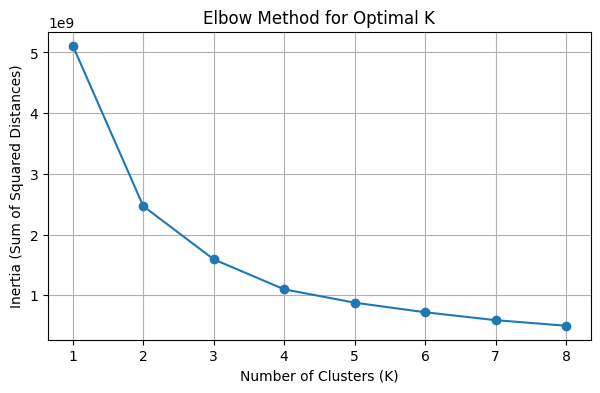

In [ ]:
from sklearn.cluster import KMeans

# Load image
img = cv2.imread('lab4_landscape.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
pixels = img_rgb.reshape(-1, 3)

# Try K values from 1 to 8
Ks = range(1, 9)
inertias = []
for k in Ks:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(pixels)
    inertias.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(7,4))
plt.plot(Ks, inertias, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.xticks(Ks)
plt.grid()
plt.show()

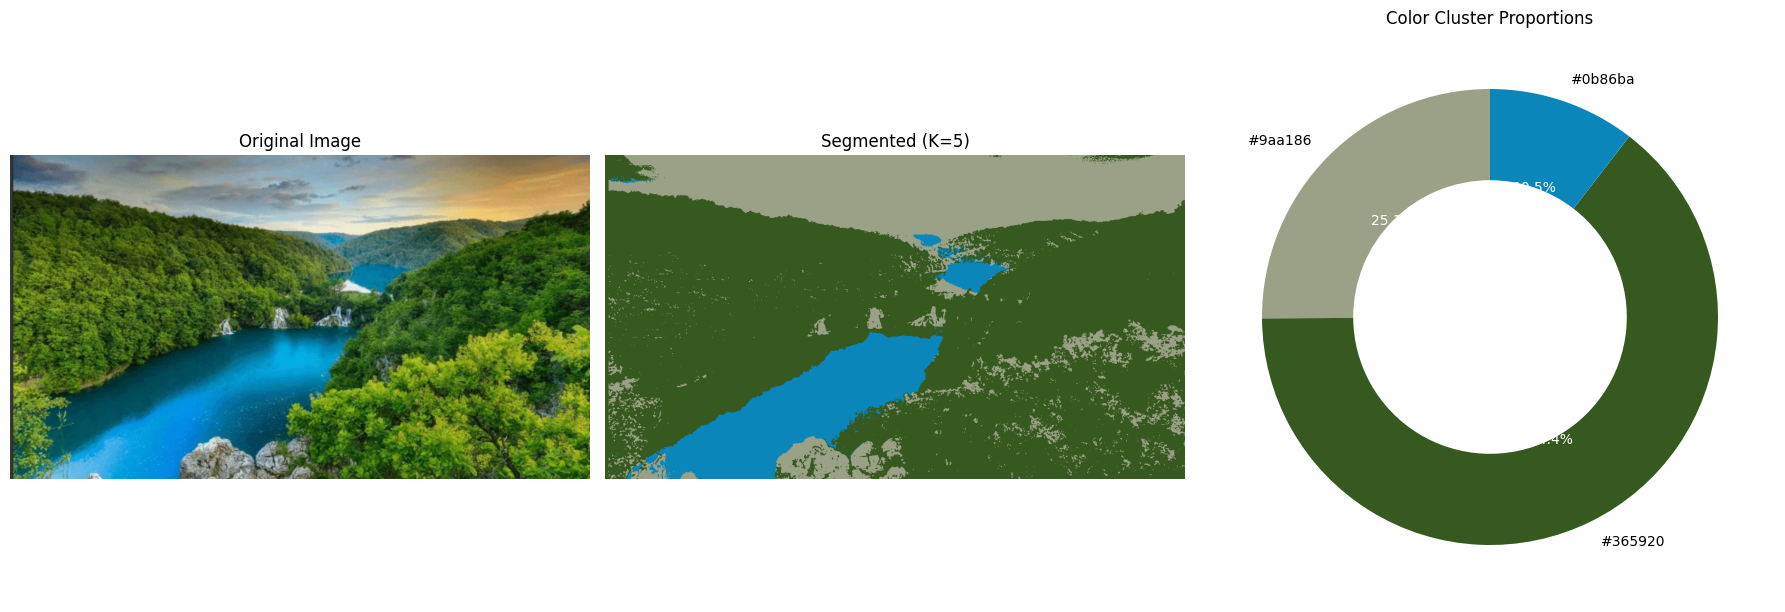

In [ ]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
pixels = img_rgb.reshape(-1, 3)

# K-means with K=3
k = 3
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
labels = kmeans.fit_predict(pixels)
palette = kmeans.cluster_centers_.astype(np.uint8)

# 3. Recreate segmented image
segmented = palette[labels].reshape(img_rgb.shape)

# 4. Prepare color codes for labels
def rgb2hex(rgb):
    return '#%02x%02x%02x' % tuple(rgb)
color_labels = [rgb2hex(color) for color in palette]

# 5. Calculate proportions
counts = np.bincount(labels)
percentages = counts / counts.sum()
colors_norm = palette / 255.0  # For matplotlib

# 6. Plot all together
fig, axs = plt.subplots(1, 3, figsize=(18,6))

# Original
axs[0].imshow(img_rgb)
axs[0].set_title('Original Image')
axs[0].axis('off')

# Segmented
axs[1].imshow(segmented)
axs[1].set_title('Segmented (K=3)')
axs[1].axis('off')

# Donut chart
wedges, texts, autotexts = axs[2].pie(
    percentages,
    colors=colors_norm,
    labels=color_labels,
    wedgeprops=dict(width=0.4),
    startangle=90,
    autopct='%1.1f%%'
)
axs[2].set_title('Color Cluster Proportions')
for autotext in autotexts:
    autotext.set_color('white')
plt.tight_layout()
plt.show()

### **Answers**
1. What do you observe about the segmented images for different values of K?

As K increases, the segmented image uses more color regions.

With a small K (e.g., 2 or 3), the image looks flat and many regions with different colors are grouped together.

As K increases (e.g., 5, 6, 7), the image preserves more color details, and regions are better separated, but can start to look patchy or noisy if K is too high.

2. Which value of K best separates visually meaningful regions in the image?

The “best” K is usually at the elbow point in the inertia curve: where adding more clusters doesn't significantly reduce error. (k=3,4,5)


3. What are some limitations of using K-means for segmentation?

No spatial awareness: K-means clusters only by color, not by position, so distant pixels of the same color are grouped even if they’re in different objects.

Ignores texture and edges: Objects of similar color but different texture/pattern are not distinguished.

4. Try segmenting an image with texture or less color variation—what happens?

K-means works best on images with clear, distinct color regions and less on images where texture or brightness are more important than color.

# Part 4: Texture Detection and Segmentation

## Objectives
- Detect and analyze textures in images using Local Binary Patterns (LBP) and Haralick features.
- Use these texture descriptors to segment and distinguish different regions in an image.
- Compare texture histograms for regions with different surface types.

---

## Instructions

1. **Load three texture images** (e.g., `sand.jpeg`, `grass.jpeg`, `gravel.jpeg`)

2. **Convert each image to grayscale** using OpenCV.

3. **Extract Local Binary Pattern (LBP) features** for each texture:
   - Use `skimage.feature.local_binary_pattern`.
   - Plot both the LBP image and the LBP histogram for each texture.

4. **Compute Haralick features** (e.g., contrast, correlation, energy, homogeneity) for each texture:
   - Use `skimage.feature.graycomatrix` and `graycoprops`.
   - Compare values in a Pandas DataFrame.

5. **Try a segmentation task**:
   - Take an image with two different textures (land water). Extract two small patches (stamps): one from water, one from landCompute and plot their LBP histograms and Haralick features Take a third random patch and “guess” its type using the features. Visualize the locations of all stamps on the image

---

In [11]:
img1=files.upload()

Saving grass.jpeg to grass.jpeg
Saving gravel.jpeg to gravel.jpeg
Saving sand.jpg to sand.jpg


In [12]:
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
import pandas as pd

# Parameters for LBP
P = 8    # Number of neighbors
R = 1    # Radius
METHOD = 'default'


images = {
    'Sand': cv2.imread('sand.jpg', cv2.IMREAD_GRAYSCALE),
    'Grass': cv2.imread('grass.jpeg', cv2.IMREAD_GRAYSCALE),
    'Gravel': cv2.imread('gravel.jpeg', cv2.IMREAD_GRAYSCALE)
}

lbp_histograms = {}
haralick_features = {}

for name, img in images.items():
    # LBP
    lbp = local_binary_pattern(img, P, R, method=METHOD)
    lbp_hist, _ = np.histogram(lbp, bins=np.arange(0, P+3), range=(0, P+2), density=True)
    lbp_histograms[name] = lbp_hist

    # Plot LBP image and histogram
    plt.figure(figsize=(8,3))
    plt.subplot(1,2,1)
    plt.imshow(lbp, cmap='gray')
    plt.title(f'{name} LBP')
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.bar(np.arange(len(lbp_hist)), lbp_hist)
    plt.title(f'{name} LBP Histogram')
    plt.xlabel('Pattern')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    # Haralick features
    img_8bit = (255*(img-img.min())/(img.max()-img.min())).astype(np.uint8)
    glcm = graycomatrix(img_8bit, [1], [0], 256, symmetric=True, normed=True)
    haralick_features[name] = {
        'contrast': graycoprops(glcm, 'contrast')[0,0],
        'correlation': graycoprops(glcm, 'correlation')[0,0],
        'energy': graycoprops(glcm, 'energy')[0,0],
        'homogeneity': graycoprops(glcm, 'homogeneity')[0,0]
    }

# Display Haralick features as DataFrame
df = pd.DataFrame(haralick_features).T
display(df)

ValueError: The parameter `image` must be a 2-dimensional array

In [2]:
img1=files.upload()

Saving land_water.jpg to land_water.jpg


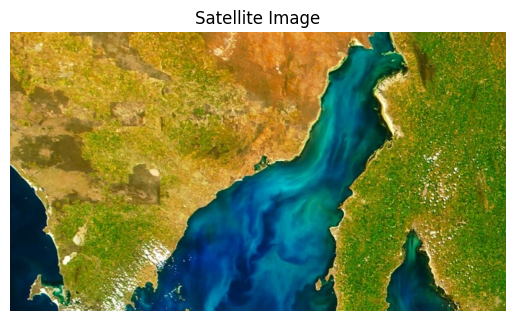

In [3]:
img = cv2.imread('land_water.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title('Satellite Image')
plt.axis('off')
plt.show()

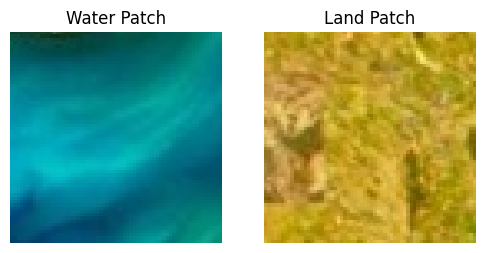

In [11]:
patch_size = 64

# Water patch
water_x, water_y = 430, 210  # e.g. coordinates in the blue area
water_patch = img_rgb[water_y:water_y+patch_size, water_x:water_x+patch_size]

# Land patch
land_x, land_y = 200, 100  # e.g. coordinates in green/brown area
land_patch = img_rgb[land_y:land_y+patch_size, land_x:land_x+patch_size]

# Show both patches
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(water_patch)
ax[0].set_title("Water Patch")
ax[1].imshow(land_patch)
ax[1].set_title("Land Patch")
for a in ax: a.axis('off')
plt.show()

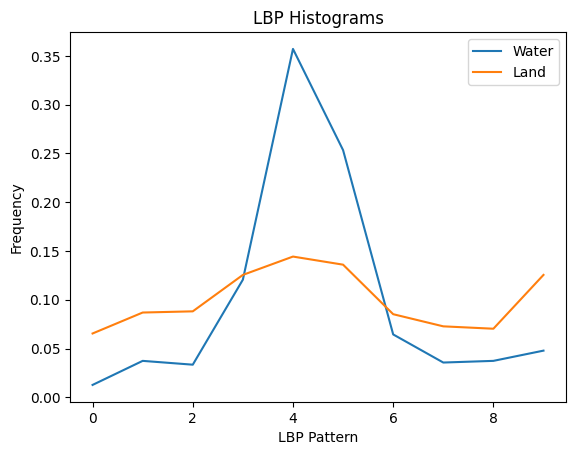

In [13]:
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
import pandas as pd

# Parameters for LBP
P = 8    # Number of neighbors
R = 1    # Radius
METHOD = 'default'


def get_lbp_hist(patch, P=8, R=1):
    gray = cv2.cvtColor(patch, cv2.COLOR_RGB2GRAY)
    lbp = local_binary_pattern(gray, P, R, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, P+3), range=(0, P+2), density=True)
    return hist

lbp_water = get_lbp_hist(water_patch)
lbp_land = get_lbp_hist(land_patch)

plt.plot(lbp_water, label='Water')
plt.plot(lbp_land, label='Land')
plt.title("LBP Histograms")
plt.xlabel('LBP Pattern')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [14]:
from skimage.feature import graycomatrix, graycoprops

def get_haralick_feats(patch):
    gray = cv2.cvtColor(patch, cv2.COLOR_RGB2GRAY)
    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    feats = {p: graycoprops(glcm, p)[0,0] for p in ['contrast', 'correlation', 'energy', 'homogeneity']}
    return feats

har_water = get_haralick_feats(water_patch)
har_land = get_haralick_feats(land_patch)

import pandas as pd
pd.DataFrame([har_water, har_land], index=['Water', 'Land'])

,contrast,correlation,energy,homogeneity
Water,5.296131,0.994448,0.043836,0.453024
Land,197.269345,0.768621,0.021547,0.095631


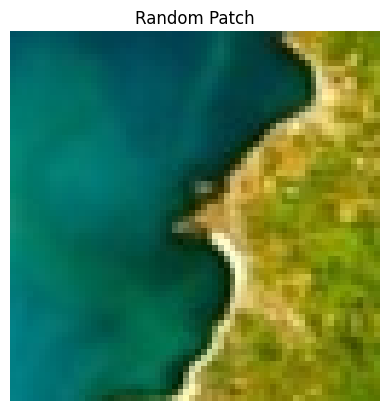

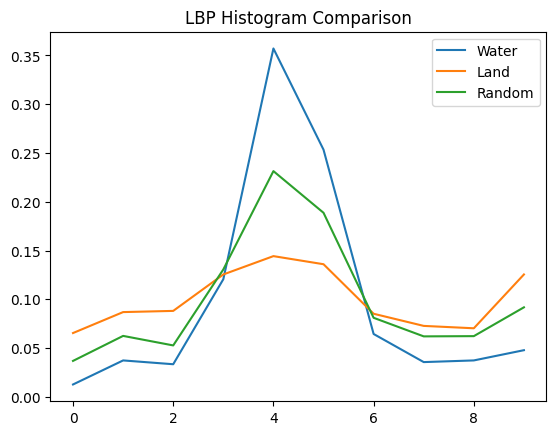

          contrast  correlation    energy  homogeneity
Water     5.296131     0.994448  0.043836     0.453024
Land    197.269345     0.768621  0.021547     0.095631
Random  355.026042     0.895615  0.031967     0.247969


In [15]:
# Pick another spot and extract patch
rand_x, rand_y = 500, 250  # Change this for a different location
rand_patch = img_rgb[rand_y:rand_y+patch_size, rand_x:rand_x+patch_size]

plt.imshow(rand_patch)
plt.title("Random Patch")
plt.axis('off')
plt.show()

# LBP & Haralick
rand_lbp = get_lbp_hist(rand_patch)
rand_har = get_haralick_feats(rand_patch)

# Plot LBP comparison
plt.plot(lbp_water, label='Water')
plt.plot(lbp_land, label='Land')
plt.plot(rand_lbp, label='Random')
plt.legend()
plt.title('LBP Histogram Comparison')
plt.show()

# Haralick comparison
df = pd.DataFrame([har_water, har_land, rand_har], index=['Water','Land','Random'])
print(df)



# **Part 6: Counting Colored Objects with Connected Components**

## **Objectives**
- Detect and count colored objects in an image using connected components analysis.
- Use color statistics to identify and classify objects by their dominant color.
- Practice color-based segmentation using OpenCV and NumPy.

---

## **Instructions**

### **1. Load the Test Image**
- Use the provided image (e.g., `shape_color.jpeg`) or another image with isolated colored shapes on a plain background.


### **2. Convert to Grayscale and Threshold**
- Convert the image to grayscale.
- Apply Otsu’s thresholding to segment foreground from background.

### **3. Morphological Cleaning**
- Use morphological closing to clean up the binary image

### **4. Connected Components Analysis**

- Use cv2.connectedComponentsWithStats() to label and extract information about each connected object.


### **5. Assign Colors and Visualize**

- For each object, compute the average color from the original image.

- Assign and display random colors to each object for visualization.

- Show the processed image with each object labeled or highlighted.

### **6. Object Classification and Counting**

- Select a target color by RGB value.

- Highlight and count the number of objects whose average color matches (within a small tolerance) the selected color

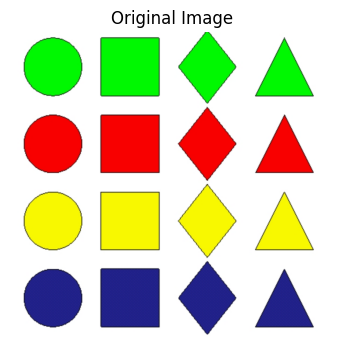

In [71]:
# DL image
img = cv2.imread('shape_color.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,4))
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')
plt.show()

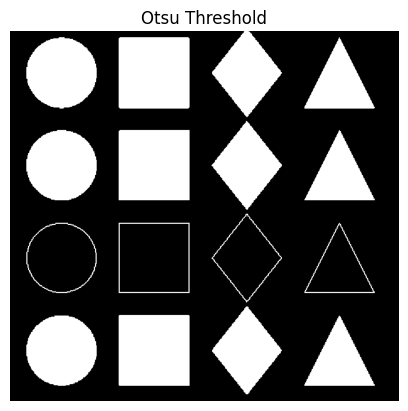

In [75]:
# Convert to Grayscale & Threshold (Otsu's method)


gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

plt.imshow(binary, cmap='gray')
plt.title('Otsu Threshold')
plt.axis('off')
plt.show()

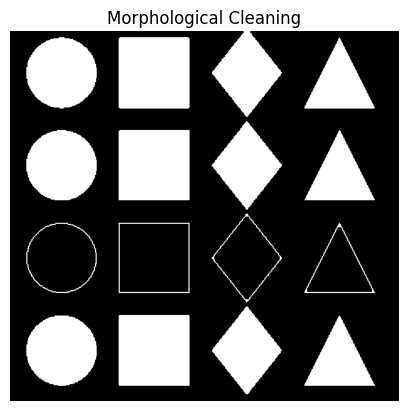

In [89]:
#Morphological Cleaning


kernel = np.ones((5,5), np.uint8)
cleaned = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=1)

plt.imshow(cleaned, cmap='gray')
plt.title('Morphological Cleaning')
plt.axis('off')
plt.show()

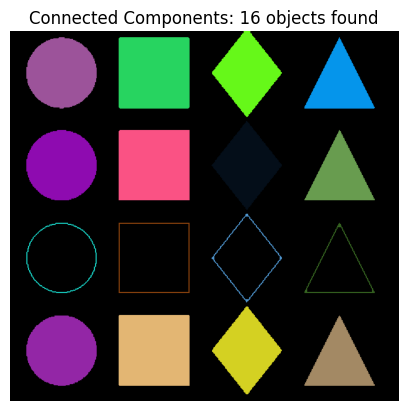

In [90]:
# Connected Components Analysis & Color Labeling
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(cleaned)

# Assign random colors to each label (object)
output = np.zeros_like(img)
colors = [(0,0,0)]  # background is black
for i in range(1, num_labels):
    color = tuple(np.random.randint(0, 255, size=3).tolist())
    colors.append(color)
    output[labels == i] = color

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f'Connected Components: {num_labels-1} objects found')
plt.axis('off')
plt.show()

In [91]:
stats

array([[     0,      0,    691,    658, 312896],
       [   359,      0,    124,    153,   9972],
       [    29,     11,    125,    127,  12307],
       [   193,     11,    126,    127,  15990],
       [   523,     11,    125,    127,   8083],
       [   358,    160,    125,    158,   9985],
       [    29,    176,    125,    125,  12297],
       [   193,    176,    126,    125,  15747],
       [   523,    176,    125,    125,   7917],
       [   358,    325,    125,    158,    776],
       [    29,    341,    125,    125,    769],
       [   193,    341,    126,    125,    988],
       [   523,    341,    125,    125,    804],
       [   359,    490,    124,    156,   9978],
       [   193,    505,    126,    126,  15873],
       [    29,    506,    125,    125,  12298],
       [   523,    506,    125,    125,   7998]], dtype=int32)

In [92]:
#Map Each Label to Original Color
from collections import Counter

label_colors = []
for i in range(1, num_labels):
    mask = (labels == i)
    # Get the average color from the original image
    color_vals = img[mask]
    avg_color = tuple(np.round(np.mean(color_vals, axis=0)).astype(int))
    label_colors.append(avg_color)

# Plot legend
for i, color in enumerate(label_colors):
    print(i,color)

0 (np.int64(5), np.int64(238), np.int64(4))
1 (np.int64(4), np.int64(238), np.int64(4))
2 (np.int64(4), np.int64(237), np.int64(3))
3 (np.int64(7), np.int64(232), np.int64(6))
4 (np.int64(4), np.int64(4), np.int64(237))
5 (np.int64(3), np.int64(3), np.int64(238))
6 (np.int64(2), np.int64(2), np.int64(237))
7 (np.int64(4), np.int64(4), np.int64(232))
8 (np.int64(38), np.int64(123), np.int64(123))
9 (np.int64(35), np.int64(106), np.int64(106))
10 (np.int64(16), np.int64(87), np.int64(87))
11 (np.int64(28), np.int64(104), np.int64(104))
12 (np.int64(133), np.int64(35), np.int64(35))
13 (np.int64(133), np.int64(33), np.int64(33))
14 (np.int64(133), np.int64(35), np.int64(34))
15 (np.int64(131), np.int64(34), np.int64(34))


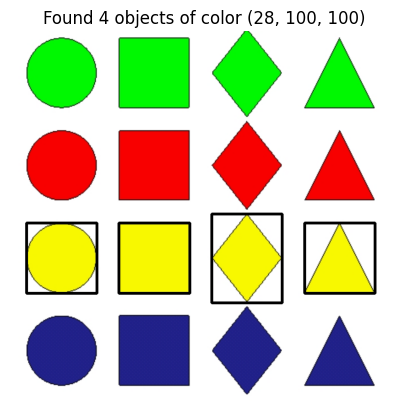

In [93]:
# User can choose by (R,G,B) value
selected_color = (0, 0, 255)  # Let's count green objects
selected_color = (28, 100, 100)  # Let's count green objects

count = 0
highlighted = img.copy()
for i, avg_color in enumerate(label_colors):
    if np.linalg.norm(np.array(avg_color) - np.array(selected_color)) < 50:  # allow small difference
        mask = (labels == (i+1))
        count += 1
        # Draw a bounding box for visual feedback
        x, y, w, h, area = stats[i+1]
        cv2.rectangle(highlighted, (x, y), (x+w, y+h), (0, 0, 0), 4)

plt.imshow(cv2.cvtColor(highlighted, cv2.COLOR_BGR2RGB))
plt.title(f'Found {count} objects of color {selected_color}')
plt.axis('off')
plt.show()
